# FakeLens 360 — AFND : audit, fuites, modèles et préparation XLM-R

Ce notebook traite **AFND (Arabic Fake News Dataset)**. Particularité importante : le label est attribué à la **source** et non article par article. Pour éviter une fuite massive, les sources du test ne doivent jamais apparaître dans l'entraînement.

Livrables produits :
- audit de qualité et doublons ;
- split sans chevauchement de sources ;
- baseline TF-IDF ;
- modèle texte + métadonnées non identifiantes ;
- analyse des erreurs ;
- système de confiance avec abstention ;
- fichiers CSV standardisés pour XLM-RoBERTa.

In [15]:
!pip install -q ijson joblib scikit-learn pandas matplotlib

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path
import sys, json, zipfile, random
import ijson
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/content/drive/MyDrive/FakeNewsDetection')
sys.path.insert(0, str(PROJECT_ROOT))

from src.fakelens_common import (
    locate_file, normalize_text, basic_audit, remove_conflicting_duplicates,
    source_stratified_split, split_overlap_report, make_text_svm,
    make_text_probability_model, make_hybrid_model, evaluate_model,
    save_confusion, confidence_table, save_errors, top_linear_features,
)

RAW_ZIP = locate_file(PROJECT_ROOT, 'AFND.zip')
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'afnd'
MODELS_DIR = PROJECT_ROOT / 'models' / 'afnd'
for path in [PROCESSED_DIR, RESULTS_DIR, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
MAX_ARTICLES_PER_SOURCE = 400   # environ 50 000 articles au maximum
print('Archive :', RAW_ZIP)

Archive : /content/drive/MyDrive/FakeNewsDetection/AFND.zip


## 1. Chargement mémoire-sûr

On parcourt chaque source en streaming et on conserve un échantillon aléatoire par réservoir. Ainsi, une source très volumineuse ne domine pas tout le dataset.

In [4]:
def reservoir_sample_articles(file_obj, k, seed):
    rng = random.Random(seed)
    sample = []
    count = 0
    for article in ijson.items(file_obj, 'articles.item'):
        count += 1
        if len(sample) < k:
            sample.append(article)
        else:
            j = rng.randint(1, count)
            if j <= k:
                sample[j - 1] = article
    return sample, count

with zipfile.ZipFile(RAW_ZIP) as archive:
    source_labels = json.loads(archive.read('AFND/sources.json').decode('utf-8'))
    rows, source_stats = [], []
    for index, (source_id, source_label) in enumerate(sorted(source_labels.items()), start=1):
        member = f'AFND/Dataset/{source_id}/scraped_articles.json'
        with archive.open(member) as file_obj:
            articles, raw_count = reservoir_sample_articles(
                file_obj, MAX_ARTICLES_PER_SOURCE, RANDOM_STATE + index
            )
        source_stats.append({
            'source_id': source_id,
            'source_label': source_label,
            'articles_bruts': raw_count,
            'articles_conserves': len(articles),
        })
        for article in articles:
            rows.append({
                'source_id': source_id,
                'source_label': source_label,
                'title': article.get('title', ''),
                'body': article.get('text', ''),
                'published_date': article.get('published date'),
            })
        if index % 20 == 0:
            print(f'{index}/134 sources traitées')

source_stats = pd.DataFrame(source_stats)
df = pd.DataFrame(rows)
print('Articles bruts recensés :', int(source_stats.articles_bruts.sum()))
print('Articles utilisés :', len(df))
source_stats.to_csv(RESULTS_DIR / 'afnd_source_counts.csv', index=False)

20/134 sources traitées
40/134 sources traitées
60/134 sources traitées
80/134 sources traitées
100/134 sources traitées
120/134 sources traitées
Articles bruts recensés : 606912
Articles utilisés : 48113


## 2. Nettoyage, labels et métadonnées

In [5]:
LABEL_3CLASS = {
    'credible': 'REAL',
    'not credible': 'FAKE',
    'undecided': 'UNCERTAIN',
}

df['title'] = df['title'].fillna('').astype(str)
df['body'] = df['body'].fillna('').astype(str)
df['text'] = (df['title'].str.strip() + '\n' + df['body'].str.strip()).str.strip()
df['label_3class'] = df['source_label'].map(LABEL_3CLASS)
df['label_binary'] = df['label_3class'].where(df['label_3class'].isin(['FAKE', 'REAL']))
df['text_norm'] = df['text'].map(normalize_text)
df['date'] = pd.to_datetime(df['published_date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['title_len'] = df['title'].str.len()
df['body_len'] = df['body'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df['has_date'] = df['date'].notna().astype(int)

df = df[df['text_norm'].str.len() >= 20].reset_index(drop=True)
display(basic_audit(df, 'text', 'label_3class'))
display(df['label_3class'].value_counts().to_frame('effectif'))


,lignes,textes_vides,doublons_texte,labels,mots_moyens,caracteres_moyens
0,48113,0,21,3,256.35,1565.82


,effectif
label_3class,
REAL,18836
FAKE,17744
UNCERTAIN,11533


## 3. Détection des doublons et contradictions

In [6]:
clean_df, duplicate_report = remove_conflicting_duplicates(
    df, text_key='text_norm', label_col='label_3class'
)
print(duplicate_report)
print('Avant :', len(df), '| Après :', len(clean_df))
pd.DataFrame([duplicate_report]).to_csv(RESULTS_DIR / 'afnd_duplicate_report.csv', index=False)

{'textes_avec_labels_contradictoires': 10, 'lignes_supprimees_total': 31}
Avant : 48113 | Après : 48082


## 4. Split anti-fuite au niveau des sources

Les 134 sources sont réparties entre train, validation et test **avant** de répartir les articles. Le même site ne peut donc pas être présent dans deux ensembles.

In [7]:
source_split = source_stratified_split(source_labels, seed=RANDOM_STATE)
clean_df = clean_df.merge(source_split[['source_id', 'split']], on='source_id', how='left')

display(pd.crosstab(clean_df['split'], clean_df['label_3class']))
overlap = split_overlap_report(clean_df, text_key='text_norm', group_col='source_id')
display(overlap)
overlap.to_csv(RESULTS_DIR / 'afnd_leakage_audit.csv', index=False)

label_3class,FAKE,REAL,UNCERTAIN
split,,,
test,2794,2586,1228
train,12259,13043,8303
valid,2672,3197,2000


,comparaison,textes_communs,groupes_communs
0,train ↔ valid,0,0
1,train ↔ test,0,0
2,valid ↔ test,0,0


## 5. Visualisations d’audit

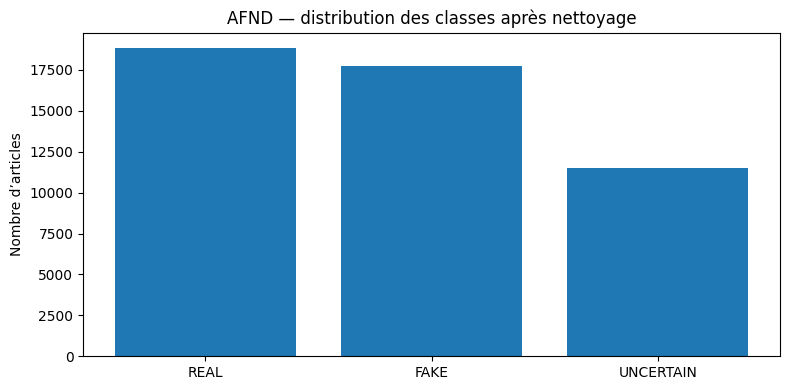

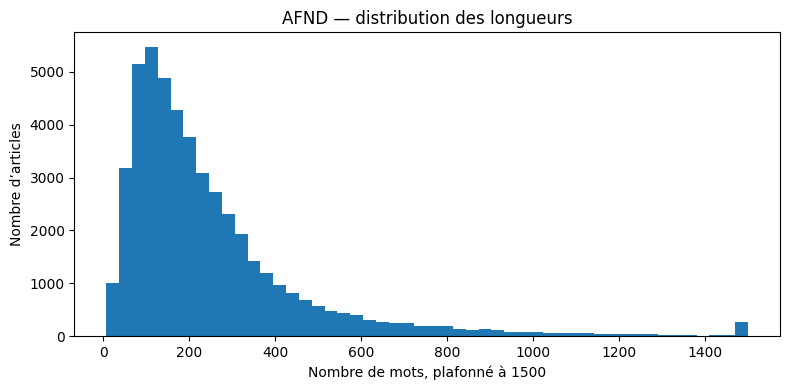

In [8]:
class_counts = clean_df['label_3class'].value_counts()
plt.figure(figsize=(8, 4))
plt.bar(class_counts.index, class_counts.values)
plt.ylabel('Nombre d’articles')
plt.title('AFND — distribution des classes après nettoyage')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'afnd_class_distribution.png', dpi=160)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(clean_df['word_count'].clip(upper=1500), bins=50)
plt.xlabel('Nombre de mots, plafonné à 1500')
plt.ylabel('Nombre d’articles')
plt.title('AFND — distribution des longueurs')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'afnd_text_lengths.png', dpi=160)
plt.show()

## 6. Préparation du benchmark binaire

In [9]:
binary = clean_df.dropna(subset=['label_binary']).copy()
train = binary[binary.split == 'train'].reset_index(drop=True)
valid = binary[binary.split == 'valid'].reset_index(drop=True)
test = binary[binary.split == 'test'].reset_index(drop=True)

print({name: len(part) for name, part in [('train', train), ('valid', valid), ('test', test)]})
print(pd.crosstab(binary['split'], binary['label_binary']))

{'train': 25302, 'valid': 5869, 'test': 5380}
label_binary   FAKE   REAL
split                     
test           2794   2586
train         12259  13043
valid          2672   3197


## 7. Baseline TF-IDF mots + caractères

modele             TF-IDF + LinearSVC
split                           valid
accuracy                     0.562276
precision_macro              0.556643
recall_macro                 0.555688
f1_macro                     0.555512
f1_weighted                  0.560417
dtype: object
              precision    recall  f1-score   support

        FAKE     0.5208    0.4820    0.5007      2672
        REAL     0.5925    0.6293    0.6103      3197

    accuracy                         0.5623      5869
   macro avg     0.5566    0.5557    0.5555      5869
weighted avg     0.5598    0.5623    0.5604      5869

modele             TF-IDF + LinearSVC
split                            test
accuracy                     0.549071
precision_macro              0.547982
recall_macro                 0.547834
f1_macro                     0.547793
f1_weighted                  0.548722
dtype: object
              precision    recall  f1-score   support

        FAKE     0.5641    0.5798    0.5718      2794
    

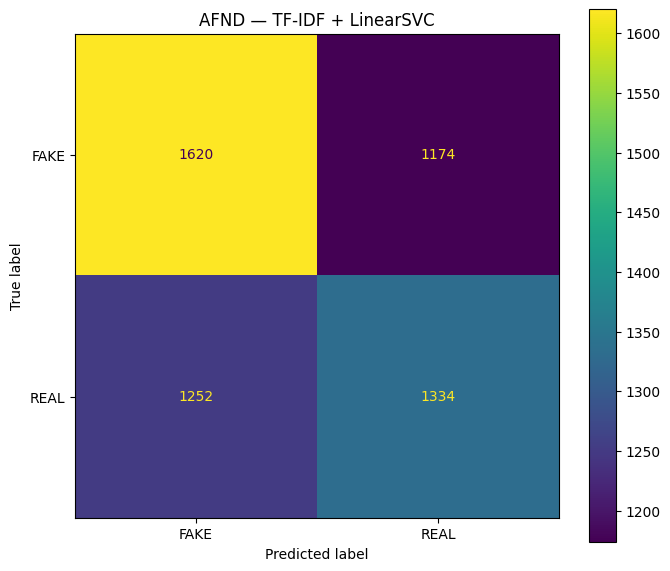

['/content/drive/MyDrive/FakeNewsDetection/models/afnd/afnd_text_svm.joblib']

In [10]:
text_svm = make_text_svm(language='ar')
text_svm.fit(train['text'], train['label_binary'])

results = []
valid_pred, result = evaluate_model(text_svm, valid['text'], valid['label_binary'], 'TF-IDF + LinearSVC', 'valid')
results.append(result)
test_pred, result = evaluate_model(text_svm, test['text'], test['label_binary'], 'TF-IDF + LinearSVC', 'test')
results.append(result)

save_confusion(
    test['label_binary'], test_pred, ['FAKE', 'REAL'],
    RESULTS_DIR / 'afnd_confusion_text_svm.png',
    'AFND — TF-IDF + LinearSVC'
)
joblib.dump(text_svm, MODELS_DIR / 'afnd_text_svm.joblib')

## 8. Modèle texte + métadonnées responsables

In [11]:
# On n’utilise PAS source_id : ce serait une fuite directe, car le label est défini par la source.
numeric_cols = ['year', 'month', 'title_len', 'body_len', 'word_count', 'has_date']
hybrid = make_hybrid_model(
    text_col='text',
    categorical_cols=[],
    numeric_cols=numeric_cols,
    language='ar',
)
hybrid.fit(train, train['label_binary'])

hybrid_valid_pred, result = evaluate_model(hybrid, valid, valid['label_binary'], 'Texte + métadonnées', 'valid')
results.append(result)
hybrid_test_pred, result = evaluate_model(hybrid, test, test['label_binary'], 'Texte + métadonnées', 'test')
results.append(result)
joblib.dump(hybrid, MODELS_DIR / 'afnd_hybrid.joblib')

results_df = pd.DataFrame(results).sort_values(['split', 'f1_macro'], ascending=[True, False])
display(results_df)
results_df.to_csv(RESULTS_DIR / 'afnd_model_comparison.csv', index=False)

modele             Texte + métadonnées
split                            valid
accuracy                      0.544727
precision_macro               0.272363
recall_macro                       0.5
f1_macro                      0.352636
f1_weighted                   0.384181
dtype: object
              precision    recall  f1-score   support

        FAKE     0.0000    0.0000    0.0000      2672
        REAL     0.5447    1.0000    0.7053      3197

    accuracy                         0.5447      5869
   macro avg     0.2724    0.5000    0.3526      5869
weighted avg     0.2967    0.5447    0.3842      5869

modele             Texte + métadonnées
split                             test
accuracy                      0.480669
precision_macro               0.240335
recall_macro                       0.5
f1_macro                       0.32463
f1_weighted                   0.312079
dtype: object
              precision    recall  f1-score   support

        FAKE     0.0000    0.0000    0.0000 

,modele,split,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
1,TF-IDF + LinearSVC,test,0.549071,0.547982,0.547834,0.547793,0.548722
3,Texte + métadonnées,test,0.480669,0.240335,0.500000,0.324630,0.312079
0,TF-IDF + LinearSVC,valid,0.562276,0.556643,0.555688,0.555512,0.560417
2,Texte + métadonnées,valid,0.544727,0.272363,0.500000,0.352636,0.384181


## 9. Système de confiance et abstention

,seuil,couverture,n_predictions,accuracy,f1_macro
0,0.5,1.000000,5380,0.574164,0.573810
1,0.6,0.556134,2992,0.607955,0.607638
2,0.7,0.243680,1311,0.644546,0.643046
3,0.8,0.073792,397,0.750630,0.745567
4,0.9,0.006134,33,0.969697,0.935673


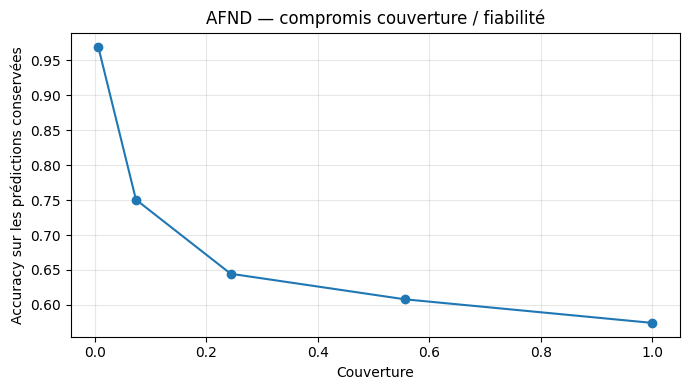

['/content/drive/MyDrive/FakeNewsDetection/models/afnd/afnd_confidence_model.joblib']

In [12]:
confidence_model = make_text_probability_model(language='ar')
confidence_model.fit(train['text'], train['label_binary'])
proba = confidence_model.predict_proba(test['text'])
pred = confidence_model.classes_[np.argmax(proba, axis=1)]
confidence = proba.max(axis=1)

abstention = confidence_table(test['label_binary'], pred, proba)
display(abstention)
abstention.to_csv(RESULTS_DIR / 'afnd_confidence_abstention.csv', index=False)

plt.figure(figsize=(7, 4))
plt.plot(abstention['couverture'], abstention['accuracy'], marker='o')
plt.xlabel('Couverture')
plt.ylabel('Accuracy sur les prédictions conservées')
plt.title('AFND — compromis couverture / fiabilité')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'afnd_coverage_accuracy.png', dpi=160)
plt.show()

joblib.dump(confidence_model, MODELS_DIR / 'afnd_confidence_model.joblib')

## 10. Analyse des erreurs et caractéristiques importantes

In [13]:
errors = save_errors(
    test, test['label_binary'], pred, confidence,
    columns=['source_id', 'title', 'text'],
    path=RESULTS_DIR / 'afnd_top_errors.csv',
)
display(errors.head(20))

features = top_linear_features(text_svm, top_n=30)
display(features)
features.to_csv(RESULTS_DIR / 'afnd_top_features.csv', index=False)

,source_id,title,text,vrai,prediction,confiance
3386,source_47,مسيرة حاشدة تطالب بتحرير البرلمان التونسي من “...,مسيرة حاشدة تطالب بتحرير البرلمان التونسي من “...,REAL,FAKE,0.902306
3840,source_49,أكثر من نصف مليون متعاف منذ بداية الجائجة بالمغرب,أكثر من نصف مليون متعاف منذ بداية الجائجة بالم...,FAKE,REAL,0.897462
3693,source_47,عون يلمح إلى انفراجة في لبنان .. لكن متى؟,عون يلمح إلى انفراجة في لبنان .. لكن متى؟\nمرص...,REAL,FAKE,0.895841
4304,source_52,ظهور نادر لوالد أمير قطر والشيخة موزا… صور,ظهور نادر لوالد أمير قطر والشيخة موزا… صور\nال...,FAKE,REAL,0.892963
3495,source_47,بسبب إساءات للراعي.. الخارجية اللبنانية تستدعي...,بسبب إساءات للراعي.. الخارجية اللبنانية تستدعي...,REAL,FAKE,0.892241
2111,source_30,كيف علّقت أيتن عامر على إصابة سمير غانم ودلال ...,كيف علّقت أيتن عامر على إصابة سمير غانم ودلال ...,FAKE,REAL,0.887058
2944,source_42,اخبار المغرب اليوم هذه تفاصيل الوضعية الوبائية...,اخبار المغرب اليوم هذه تفاصيل الوضعية الوبائية...,FAKE,REAL,0.886643
3969,source_49,توقعات أحوال أحوال الطقس اليوم الخميس,توقعات أحوال أحوال الطقس اليوم الخميس\nتتوقع ا...,FAKE,REAL,0.885687
3594,source_47,السيسي محذرا إثيوبيا: كل الخيارات متاحة,السيسي محذرا إثيوبيا: كل الخيارات متاحة\nمرصد ...,REAL,FAKE,0.879842
3714,source_47,نصر الله يهدد الحكومة اللبنانية: سأتحرك منفرداً,نصر الله يهدد الحكومة اللبنانية: سأتحرك منفردا...,REAL,FAKE,0.878046


,feature,coefficient,direction
0,char__-ال,-3.659616,FAKE
1,word__يهمك,-3.518228,FAKE
2,char__ /6,-3.071722,FAKE
3,word__بناصا,-3.043856,FAKE
4,word__موضوع يهمك,-3.034643,FAKE
5,char__”.,-2.837232,FAKE
6,word__عراق الخير,-2.352587,FAKE
7,word__شبكة عراق,-2.322503,FAKE
8,word__متاريس,-2.314107,FAKE
9,word__مشاركة,-2.269933,FAKE


## 11. Export standardisé pour XLM-RoBERTa

In [14]:
for split_name in ['train', 'valid', 'test']:
    part = clean_df[clean_df.split == split_name].copy()
    standardized = pd.DataFrame({
        'text': part['text'],
        'label_original': part['source_label'],
        'label_3class': part['label_3class'],
        'label_binary': part['label_binary'],
        'dataset': 'AFND',
        'language': 'ar',
        'split': split_name,
        'source': part['source_id'],
        'title': part['title'],
        'date': part['published_date'],
    })
    standardized.to_csv(PROCESSED_DIR / f'afnd_{split_name}_standardized.csv', index=False)

print('Exports créés dans :', PROCESSED_DIR)
print('Étape suivante : exécuter le notebook FakeNewsNet, puis le notebook XLM-R.')

Exports créés dans : /content/drive/MyDrive/FakeNewsDetection/data/processed
Étape suivante : exécuter le notebook FakeNewsNet, puis le notebook XLM-R.
